In [43]:
from data_analysis import *
import pandas as pd
from functools import reduce
from prince import MCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import copy

# Partie 2 - Données Images

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/constance/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [45]:
for root, dirs, files in os.walk(path):

    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

    if level < 3: 
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  
            print(f'{subindent}{file}')

2/
  list_eval_partition.csv
  list_attr_celeba.csv
  list_bbox_celeba.csv
  list_landmarks_align_celeba.csv
  img_align_celeba/
    img_align_celeba/
      052628.jpg
      110369.jpg
      161590.jpg
      065084.jpg
      108526.jpg


## 1. Analyse du jeu de données

In [46]:
faces = Celeb_Faces(path)
faces.load_data()

### Analyse descriptive du jeu de données

Pour cette analyse descriptive on se base uniquement sur les fichiers CSV descriptifs des images et non pas les images directement.

In [47]:
analyzers = {} 

for key, df in faces.data.items():
    if df is not None:
        print(f"\n Analyse de : {key}")
        analyzers[key] = Analyzer(df) 
        inventory = analyzers[key].get_inventory()
        print(inventory)


 Analyse de : attr_df
Dataset ready: 202599 rows and 41 columns.
                 Column   Type  Cardinality  Missing                   Details
0              image_id    str       202599        0  Examples: ['000001.jpg']
1      5_o_Clock_Shadow  int64            2        0    Unique values: [-1, 1]
2       Arched_Eyebrows  int64            2        0    Unique values: [1, -1]
3            Attractive  int64            2        0    Unique values: [1, -1]
4       Bags_Under_Eyes  int64            2        0    Unique values: [-1, 1]
5                  Bald  int64            2        0    Unique values: [-1, 1]
6                 Bangs  int64            2        0    Unique values: [-1, 1]
7              Big_Lips  int64            2        0    Unique values: [-1, 1]
8              Big_Nose  int64            2        0    Unique values: [-1, 1]
9            Black_Hair  int64            2        0    Unique values: [-1, 1]
10           Blond_Hair  int64            2        0    Unique va

- "Attr_df" contient les descriptions de chacune des images à travers une table de booléens pour indiquer si chacun de attributs est présent dans l'image en question.
- "Partition_df" contient les informations de la répartition du jeu de données en train/valid/test. Les images sont attribuées à une catégorie à partir de leur ID.
- "Bbox_df" contient les rectangles ciblant les visages de chacune des célébrités (pour chacune d'entre elles on dispose du coin inférieur gauche, de la largeur et de la hauteur).
- "Landmarks_df" contient les coordonnées (x,y) des yeux gauches et droits, du nez ainsi que des extrêmités gauches et droites de la bouche.


Aucune donnée n'est manquante.

A présent je veux merge l'ensemble des tableaux pour faire un super tableau (on image_id) et analyser les données.

In [48]:
faces_global = reduce(lambda left, right: left.merge(right, on='image_id', how='inner'), faces.data.values())
print(faces_global)
global_analyser = Analyzer(faces_global)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                



In [49]:
global_analyser.plot_distributions()

### Analyse des corrélations entre attributs. Quelles sont les variables les plus corrélées ? Exhiber au moins une corrélation artificielle. Commenter.

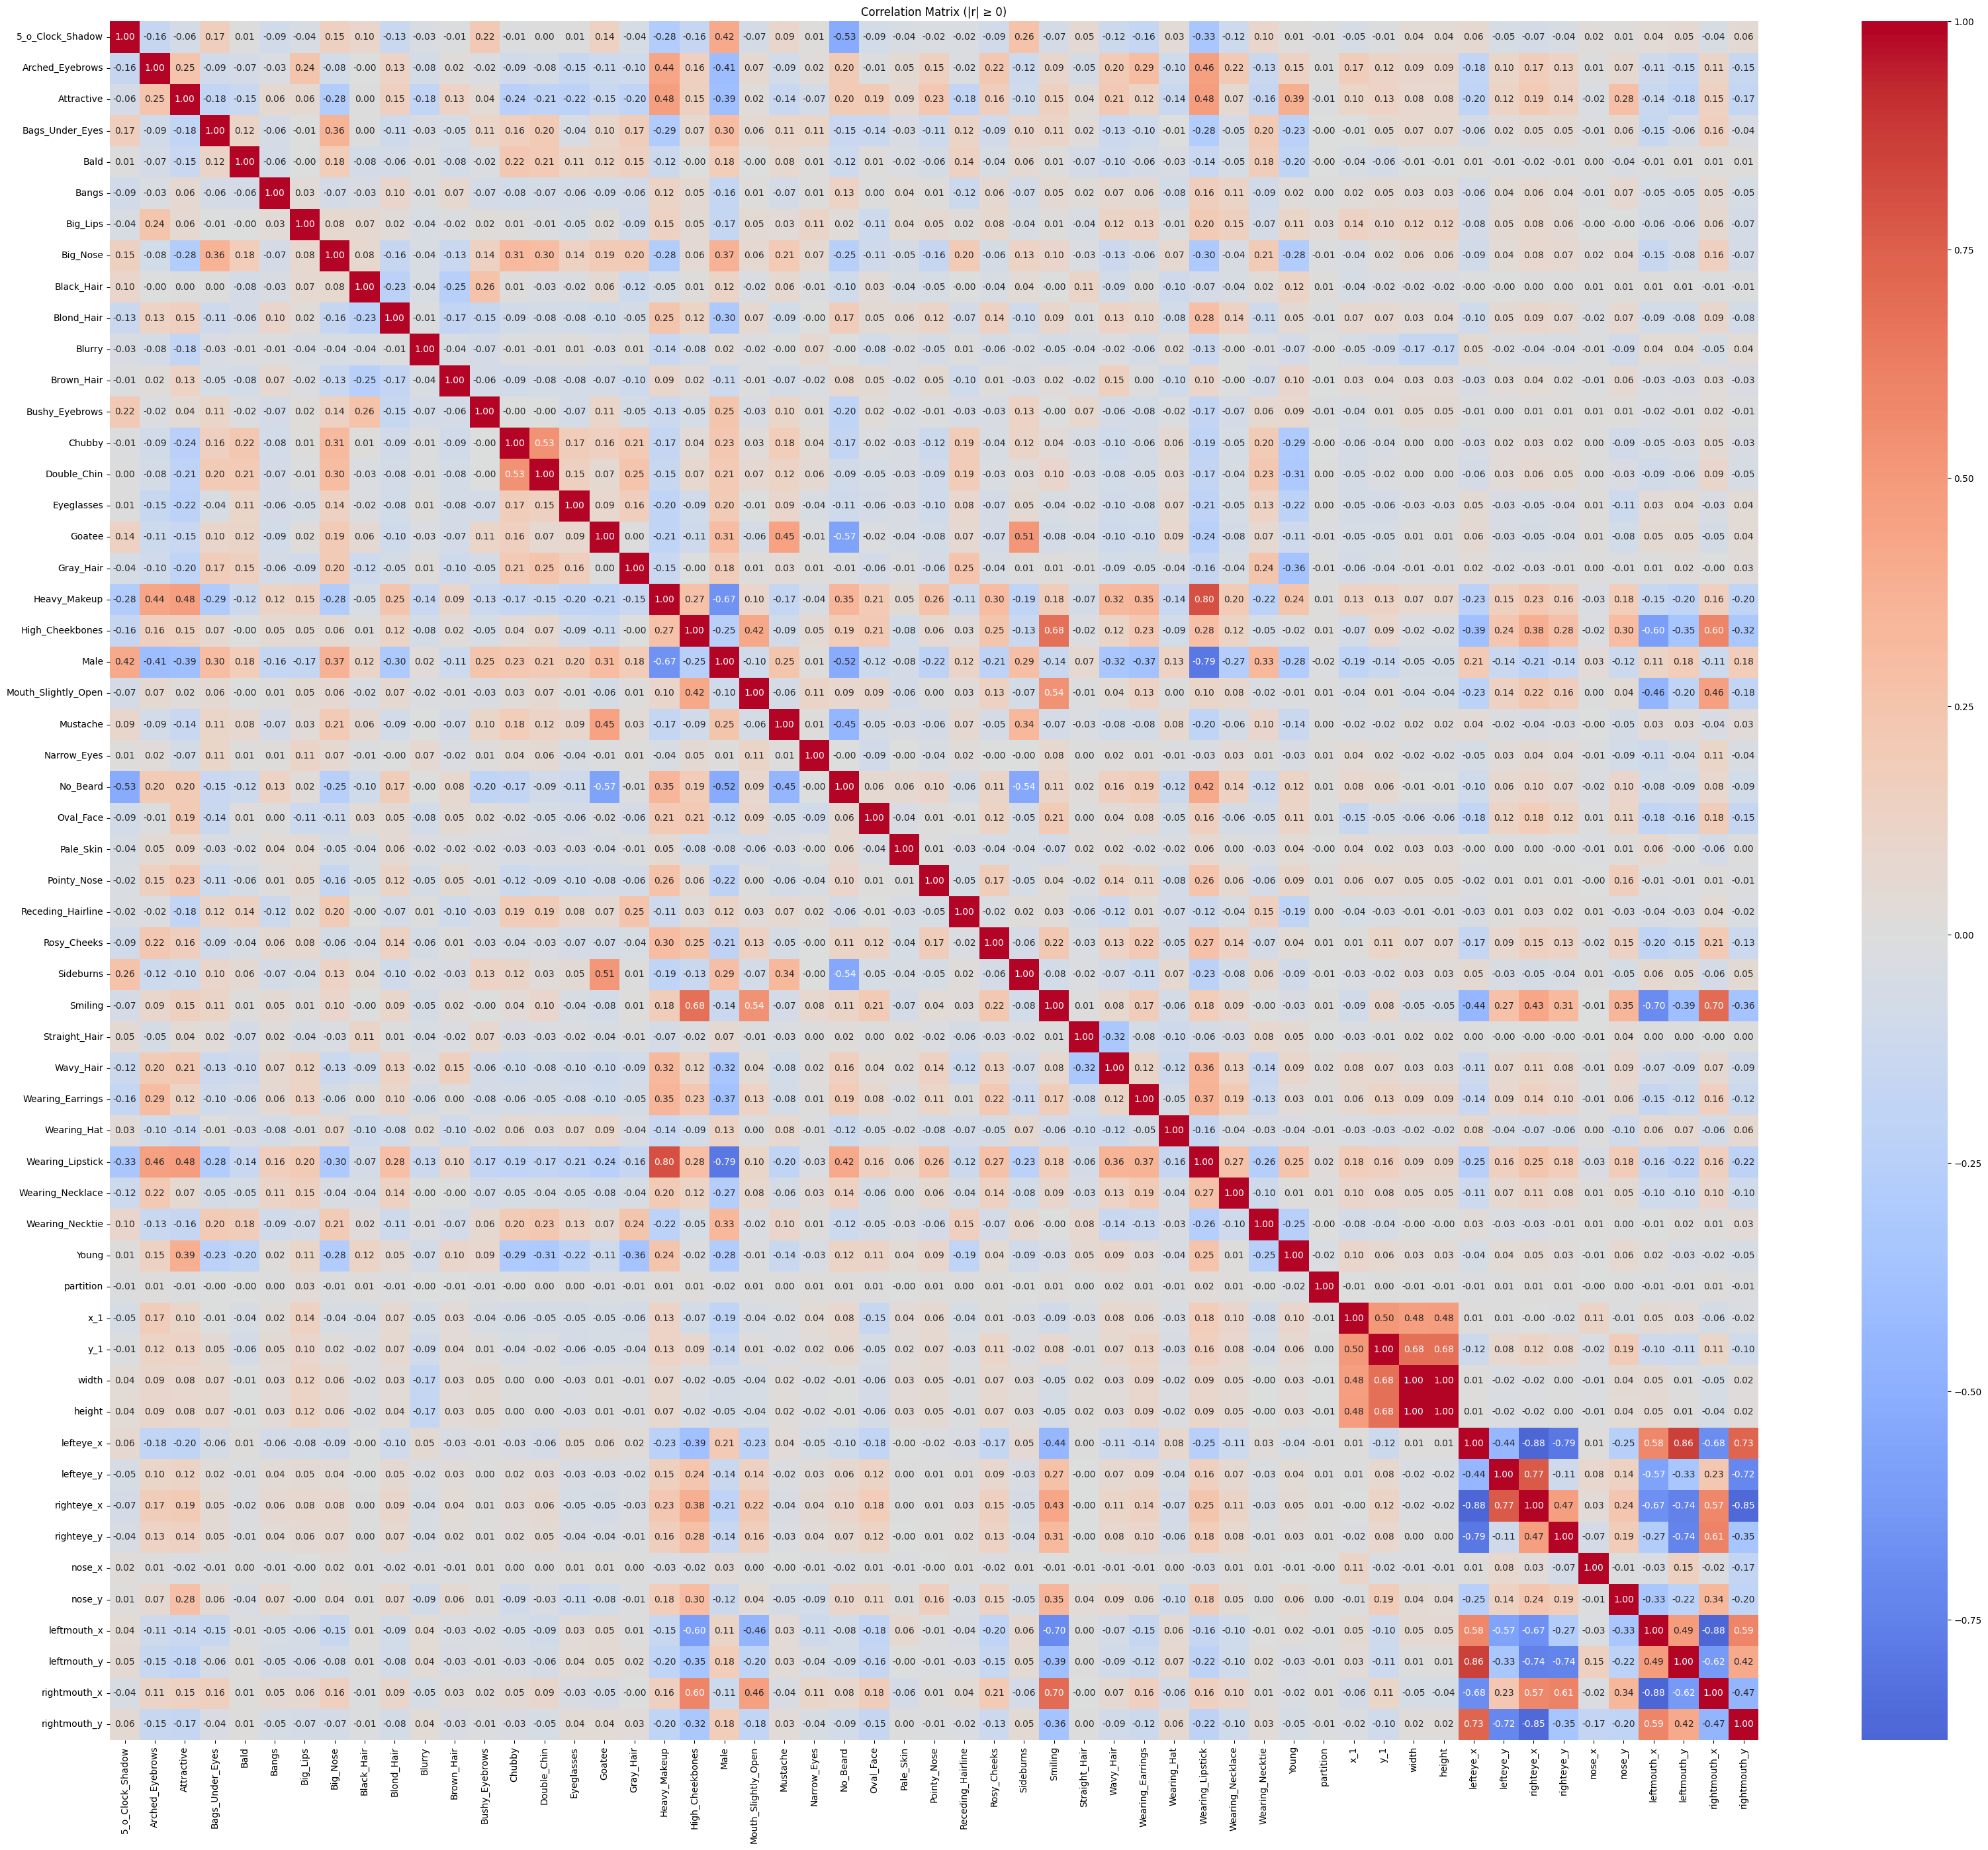

In [50]:
global_analyser.plot_matrix_correlation(0)

### Corrélation artificielle — coordonnées landmarks

Les variables `lefteye_x`, `righteye_x`, `leftmouth_x`, `rightmouth_x` et leurs homologues en y forment un **bloc de corrélations fortes** (|r| jusqu'à 0.88) entre elles. Ces corrélations sont **artificielles** : elles ne reflètent aucune réalité sémantique, mais simplement le fait que les landmarks sont définis dans le même système de coordonnées image. Si le visage est centré à droite, tous les x augmentent ensemble — la corrélation est géométrique, pas attributaire.

De même, `width` et `height` (taille du bounding box) sont corrélés à 1.00 : les visages sont recadrés avec un ratio fixe, rendant ces deux variables redondantes.

Pour plus de lisibilité, on utilise maintenant un seuil à 0.5 pour ne garder que les variables les plus corrélées entre elles.

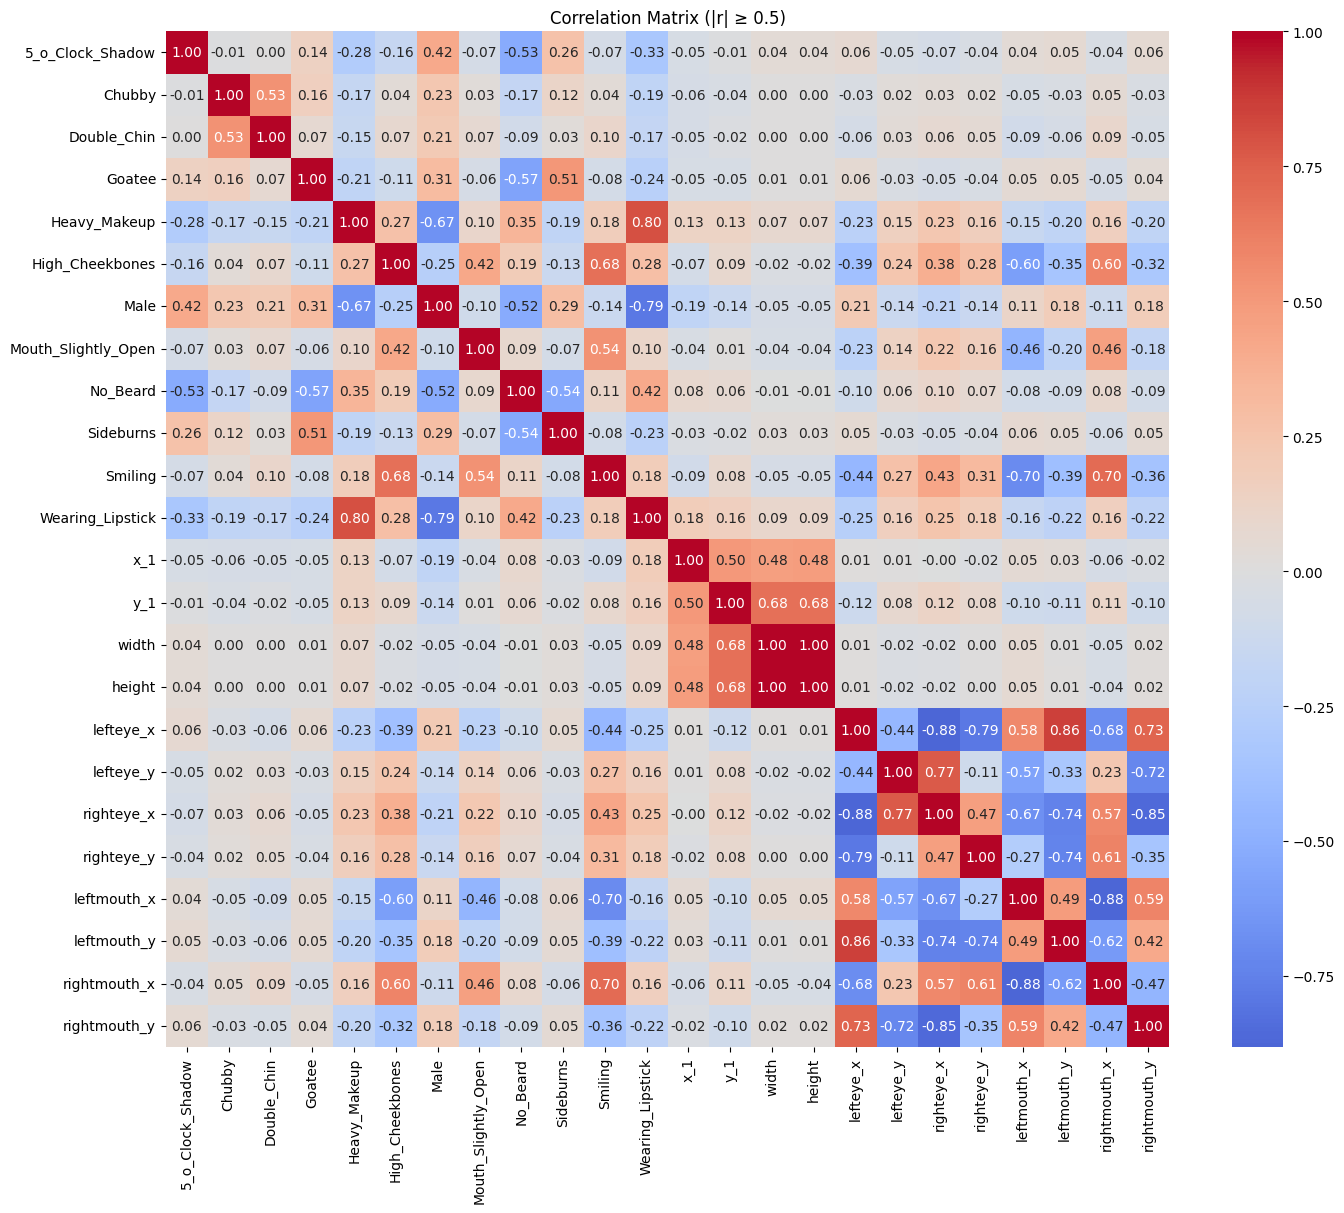

In [51]:
global_analyser.plot_matrix_correlation(0.5)

### Variables les plus corrélées (|r| ≥ 0.5)

**Corrélations sémantiquement attendues**

| Paire | r | Explication |
|---|---|---|
| Male ↔ Wearing_Lipstick | -0.79 | Attribut quasi exclusivement féminin |
| Male ↔ Heavy_Makeup | -0.67 | Idem |
| Male ↔ No_Beard | -0.52 | Logique structurelle |
| No_Beard ↔ Goatee | -0.57 | Incompatibilité directe |
| No_Beard ↔ Sideburns | -0.54 | Idem |
| Heavy_Makeup ↔ Wearing_Lipstick | +0.80 | Co-occurrence cosmétique |
| Smiling ↔ High_Cheekbones | +0.68 | Le sourire fait remonter les pommettes |
| Smiling ↔ Mouth_Slightly_Open | +0.54 | Mécanique faciale directe |
| Chubby ↔ Double_Chin | +0.53 | Co-occurrence morphologique |

Les corrélations les plus fortes sont soit **sémantiquement cohérentes** (genre, cosmétiques, morphologie), soit **artificielles** (landmarks géométriques, bounding box). Ces dernières doivent être supprimées ou normalisées avant tout entraînement pour éviter des fuites d'information géométrique dans le modèle.

### Identification de variables sensibles (ex. Genre (male/female), Couleur de peau, Âge, Contexte culturel. Justifier votre classification (pour sont-elles sensibles ? …)

### Variables directement sensibles

| Variable | Motif |
|---|---|
| `Male` | Caractéristique protégée (genre) |
| `Young` | Caractéristique protégée (âge) |
| `Pale_Skin` | Proxy direct de l'ethnie/couleur de peau (Art. 9 RGPD) |
| `Attractive` | Jugement subjectif sur l'apparence physique |
| `Chubby` | Donnée corporelle relevant de la vie privée |

### Variables à risque indirect (proxys potentiels)

| Variable | Biais potentiel |
|---|---|
| `Heavy_Makeup`, `Wearing_Lipstick` | Fortement corrélées au genre perçu |
| `No_Beard`, `Goatee`, `Mustache`, `Sideburns` | Proxy du genre masculin |
| `Wearing_Earrings`, `Wearing_Necklace` | Marqueurs de genre stéréotypés |
| `Wearing_Hat` | Peut refléter une appartenance culturelle ou religieuse |
| `Big_Nose`, `Big_Lips` | Attributs subjectifs potentiellement corrélés à l'ethnie |
| `Gray_Hair`, `Receding_Hairline` | Proxys de l'âge avancé |

### Analyse de disparité: Certains groupes sont-ils sous-représentés ? Le dataset reflète-t-il un biais de collecte ? Révèle-t-il d’autres biais ?

Afin de ne pas définir les groupes à la main, on utilise une analyse de correspondance multiple afin de définir des personnas. L'idée est ensuite de compter le nombre de personne correspondant à chacun de ces profils. On calcule alors le pourcentage de chacun des attributs par personna (ils sont binaires). L'analyse est fondée sur le dataframe attr_df.

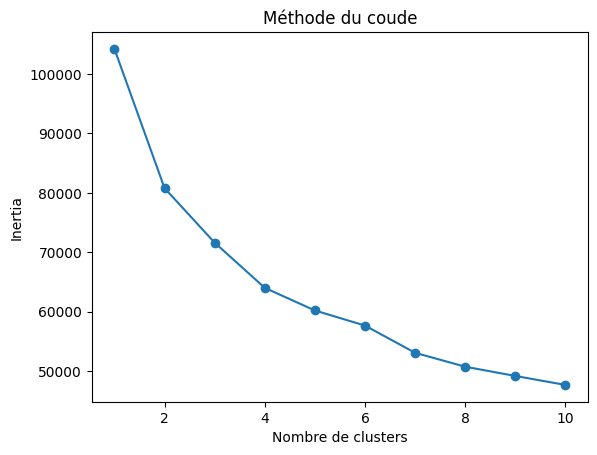

In [52]:
df_num = faces.data["attr_df"].drop(columns=['image_id']).copy()  # numérique (-1/1)
df_cat = df_num.astype(str)  # pour MCA

mca = MCA(n_components=10, random_state=42)
X_mca = mca.fit_transform(df_cat)

inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_mca)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

In [53]:
k_opt = 6  
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df_num["persona"] = kmeans.fit_predict(X_mca)

In [54]:
centroids = kmeans.cluster_centers_  # shape = (k_opt, n_components)

from scipy.spatial.distance import cdist

distances = cdist(X_mca, centroids, metric='euclidean')  # shape = (n_individus, k_opt)

similarity_scores = 1 / (1 + distances)  
similarity_scores.shape

(202599, 6)

In [55]:
intra_scores = []

for c in range(k_opt):
    members = np.where(df_num["persona"] == c)[0]
    intra_scores.append(similarity_scores[members, c].mean())

print("Intra-cluster scores:", intra_scores)

Intra-cluster scores: [0.667164257756645, 0.6871670770541201, 0.6698208830078539, 0.6251655454781735, 0.6233028013506177, 0.6725455788227398]


In [56]:
colonnes_attributs = [a for a in df_num.columns if a not in ['image_id', 'persona']]
print(colonnes_attributs)

['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


In [57]:
df_bin = (df_num[colonnes_attributs] == 1).astype(int)
df_bin['persona'] = df_num['persona']

attribute_counts_raw = df_bin.groupby('persona')[colonnes_attributs].sum()
attribute_counts_raw['cluster_size'] = df_num.groupby('persona').size()

print(attribute_counts_raw)

         5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  Bald  \
persona                                                                         
0                   15454             2020       11607             9645   155   
1                     715             5221       15665             3825   168   
2                       1            42620       64700             5195     3   
3                     926              735         190             8077  3098   
4                    4526              970        2906             4766   970   
5                     894             2524        8765             9938   153   

         Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  Smiling  \
persona                                                     ...            
0         1241      4086      8996       11574         226  ...     8723   
1         8609      7935      3952        8778        4767  ...     1780   
2        15201     26667      6882       15694 

In [58]:
attribute_counts = attribute_counts_raw.assign(
    **{col: (attribute_counts_raw[col] / attribute_counts_raw['cluster_size']*100).round() 
       for col in attribute_counts_raw.columns if col != 'cluster_size'}
)

print(attribute_counts)

         5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  Bald  \
persona                                                                         
0                    66.0              9.0        49.0             41.0   1.0   
1                     2.0             11.0        34.0              8.0   0.0   
2                     0.0             55.0        84.0              7.0   0.0   
3                     6.0              5.0         1.0             57.0  22.0   
4                    30.0              7.0        19.0             32.0   7.0   
5                     3.0              9.0        32.0             37.0   1.0   

         Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  Smiling  \
persona                                                     ...            
0          5.0      17.0      38.0        49.0         1.0  ...     37.0   
1         19.0      17.0       9.0        19.0        10.0  ...      4.0   
2         20.0      35.0       9.0        20.0 

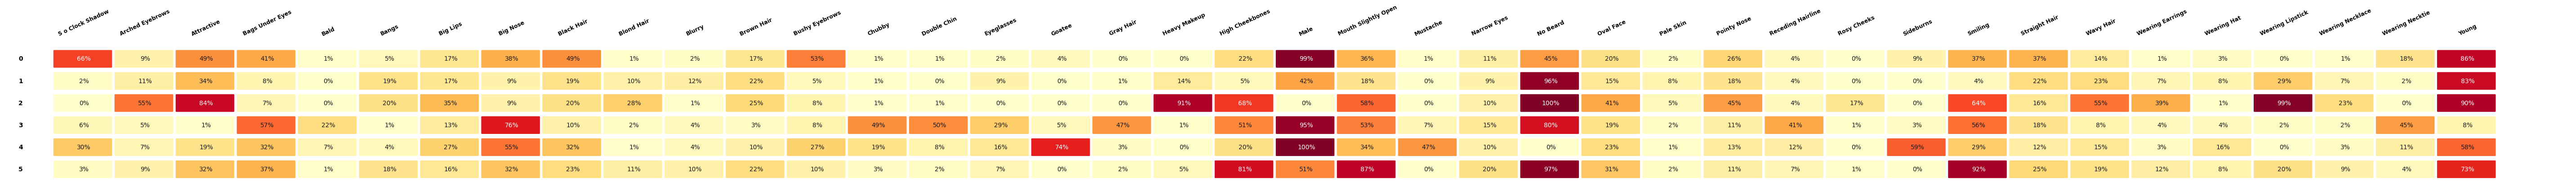

In [59]:
plot_table_attr(attribute_counts, colonnes_attributs)

In [60]:
bias_report(attribute_counts, colonnes_attributs)

── Personas biaisés (attributs > 70%) ──

🔴 2 (5 attributs forts)
   No_Beard               100.0%  ██████████
   Wearing_Lipstick        99.0%  █████████
   Heavy_Makeup            91.0%  █████████
   Young                   90.0%  █████████
   Attractive              84.0%  ████████

🔴 5 (5 attributs forts)
   No_Beard                97.0%  █████████
   Smiling                 92.0%  █████████
   Mouth_Slightly_Open     87.0%  ████████
   High_Cheekbones         81.0%  ████████
   Young                   73.0%  ███████

🔴 3 (3 attributs forts)
   Male                    95.0%  █████████
   No_Beard                80.0%  ████████
   Big_Nose                76.0%  ███████

🟡 0 (2 attributs forts)
   Male                    99.0%  █████████
   Young                   86.0%  ████████

🟡 1 (2 attributs forts)
   No_Beard                96.0%  █████████
   Young                   83.0%  ████████

🟡 4 (2 attributs forts)
   Male                   100.0%  ██████████
   Goatee                

Analyse de disparité et biais du dataset : Les personas issus de l'ACM révèlent des regroupements très marqués. Les attributs affichés étant ceux présents à **plus de 70%**, l'analyse se limite aux signaux positifs observés.

#### Synthèse des personas

| Persona | Attributs dominants (>70%) | Profil inféré |
|---------|---------------------------|---------------|
| 2 | No_Beard, Lipstick, Heavy_Makeup, Young, Attractive | Féminin maquillé, jeune |
| 5 | No_Beard, Smiling, Mouth_Open, High_Cheekbones, Young | Féminin expressif, jeune |
| 3 | Male, No_Beard, Big_Nose | Masculin, traits marqués |
| 0 | Male, Young | Masculin jeune |
| 1 | No_Beard, Young | Jeune, genre non déterminable |
| 4 | Male, Goatee | Masculin mature |

#### Biais identifiés

**Biais esthétique genré** — Les personas à dominante féminine (2, 5) sont définis par des attributs cosmétiques (*Lipstick*, *Heavy_Makeup*, *Attractive*), tandis que les personas masculins le sont par des attributs morphologiques neutres. Les femmes sont sur-annotées selon des critères de mise en scène.

**Biais d'âge** — *Young* apparaît dans 4 personas sur 6. Aucun persona féminin âgé n'émerge, alors qu'un persona masculin âgé existe (3). Les femmes âgées sont structurellement sous-représentées.

**Biais de collecte probable** — La concentration de *Smiling*, *Attractive* et *Heavy_Makeup* pointe vers une source d'images posées ou médiatiques (célébrités, réseaux sociaux), éloignée d'une distribution naturelle de population.

### Analyse de la fairness: nous allons nous intéresser aux deux métriques de fairness ci-dessous. Elles se basent sur un attribut sensible (S) et comparent avec un attribut à étudier (Y). Nous allons considérer deux attributs sensibles: Male et Pale_Skin. Calculer la valeur de ces métriques pour tous les autres attributs. 

In [61]:
m1_Male= demographic_parity(faces_global, "Attractive", "Male")
m2_Male= disparate_impact(faces_global, "Attractive", "Male")
print(m1_Male, m2_Male)

m1_PaleSkin= demographic_parity(faces_global, "Attractive", "Pale_Skin")
m2_PaleSkin= disparate_impact(faces_global, "Attractive", "Pale_Skin")
print(m1_PaleSkin, m2_PaleSkin)

-0.3999094186637652 0.4111783031823483
0.21215639998086233 1.4214523716894203


In [62]:
fairness_source = faces.data["attr_df"].copy()
fairness_targets = [col for col in fairness_source.columns if col not in ["image_id", "Male", "Pale_Skin"]]

dict_demo_male = {}
dict_disp_male = {}
dict_demo_paleskin = {}
dict_disp_paleskin = {}

for column in fairness_targets:
    dict_demo_male[column] = demographic_parity(fairness_source, column, "Male")
    dict_disp_male[column] = disparate_impact(fairness_source, column, "Male")
    dict_demo_paleskin[column] = demographic_parity(fairness_source, column, "Pale_Skin")
    dict_disp_paleskin[column] = disparate_impact(fairness_source, column, "Pale_Skin")

print("dict_demo_male", dict_demo_male)
print("dict_disp_male", dict_disp_male)
print("dict_demo_paleskin", dict_demo_paleskin)
print("dict_disp_paleskin", dict_disp_paleskin)

dict_demo_male {'5_o_Clock_Shadow': 0.2662636986940193, 'Arched_Eyebrows': -0.3661073665752317, 'Attractive': -0.3999094186637652, 'Bags_Under_Eyes': 0.24633998748264985, 'Bald': 0.05350750604260371, 'Bangs': -0.11875349321547955, 'Big_Lips': -0.14523800855663938, 'Big_Nose': 0.317357286691396, 'Black_Hair': 0.1006195395437432, 'Blond_Hair': -0.2182226753574814, 'Blurry': 0.010872606754028673, 'Brown_Hair': -0.09213601326522353, 'Bushy_Eyebrows': 0.17500440449207885, 'Chubby': 0.10889046779993176, 'Double_Chin': 0.08879790786132624, 'Eyeglasses': 0.10112058114396531, 'Goatee': 0.1503388556516929, 'Gray_Hair': 0.07499132299249324, 'Heavy_Makeup': -0.6586427289082591, 'High_Cheekbones': -0.2526747034565337, 'Mouth_Slightly_Open': -0.1009578606235979, 'Mustache': 0.0996264108099773, 'Narrow_Eyes': 0.0089254255006158, 'No_Beard': -0.39323825108296695, 'Oval_Face': -0.11008648275836533, 'Pointy_Nose': -0.19725060888444, 'Receding_Hairline': 0.06451316831351092, 'Rosy_Cheeks': -0.10752361657

#### Métriques de fairness étudiées 

- **Demographic Parity** : différence de taux positif entre les deux groupes → valeur entre -1 et 1, idéalement 0
- **Disparate Impact** : ratio de taux positif entre les deux groupes → idéalement 1, < 0.8 signale une discrimination


#### Résultats — Variable sensible : Male

**Disparités fortes (Demographic Parity)**

| Attribut | DP | Interprétation |
|---|---|---|
| Wearing_Lipstick | -0.799 | Quasi exclusivement féminin |
| Heavy_Makeup | -0.659 | Idem |
| Attractive | -0.400 | Les femmes sont plus souvent labellisées attractives |
| No_Beard | -0.393 | Logique structurelle |
| Wavy_Hair | -0.306 | Plus fréquent chez les femmes |

**Disparate Impact critique (< 0.1)**

`Wearing_Lipstick` (0.008) et `Heavy_Makeup` (0.004) ont un DI quasi nul : les hommes ne reçoivent presque jamais ces labels. À l'inverse, `Mustache` (3925), `5_o_Clock_Shadow` (1574), `Sideburns` (1455) sont massivement masculins.


#### Résultats — Variable sensible : Pale_Skin

Les écarts sont nettement plus faibles. Aucun attribut ne dépasse |0.21| en DP. Les DI restent proches de 1 pour la majorité des attributs, à l'exception de `Rosy_Cheeks` (0.21) et `Goatee` (0.21) qui sont rares chez les personnes à peau claire.

### Conclusion

Les biais les plus sévères sont liés au genre : les attributs cosmétiques et faciaux sont extrêmement polarisés entre hommes et femmes, ce qui reflète à la fois la réalité sociale et un biais d'annotation. La variable `Pale_Skin` ne génère pas de disparités significatives dans ce dataset.

## 2. Apprentissage automatique

Avant de commencer l'entrainement, on veut vérifier que les proportions des différents attributs dans train/valid/test sont proches.

On merge les tableaux attr_df et partition_df afin de vérifier facilement les proportions dans chacun des splits pour les différents attributs.

In [63]:
attr_partition = faces.data["attr_df"].merge(faces.data["partition_df"], on='image_id', how='inner')
print(attr_partition)

nb_part = attr_partition['partition'].value_counts().sort_index()
print(nb_part)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                

On convertit les colonnes d'attributs en binaire afin de faciliter le groupby - notamment éviter tout problème avec les -1.

In [64]:
attr_binary = copy.deepcopy(attr_partition)
print(attr_binary)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                

In [65]:
attr_binary[colonnes_attributs] = (attr_binary[colonnes_attributs] == 1).astype(int)
attr_binary = attr_binary.groupby('partition')[colonnes_attributs].sum()
print(attr_binary)

           5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
partition                                                                   
0                     18177            43278       83603            33280   
1                      2345             5134       10332             4121   
2                      1994             5678        9898             4045   

           Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
partition                                                           ...   
0          3713  24685     39213     38341       38906       24267  ...   
1           411   2915      3044      4943        4144        3056  ...   
2           423   3109      6528      4232        5422        2660  ...   

           Sideburns  Smiling  Straight_Hair  Wavy_Hair  Wearing_Earrings  \
partition                                                                   
0               9156    78080          33947      51982             30362   
1      

On regarde les pourcentages de chacun des attributs présents dans chaque split.

In [66]:
attr_binary[colonnes_attributs] = (attr_binary[colonnes_attributs].div(attr_binary.index.map(nb_part), axis=0)*100).round()

print(attr_binary)

           5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
partition                                                                   
0                      11.0             27.0        51.0             20.0   
1                      12.0             26.0        52.0             21.0   
2                      10.0             28.0        50.0             20.0   

           Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
partition                                                           ...   
0           2.0   15.0      24.0      24.0        24.0        15.0  ...   
1           2.0   15.0      15.0      25.0        21.0        15.0  ...   
2           2.0   16.0      33.0      21.0        27.0        13.0  ...   

           Sideburns  Smiling  Straight_Hair  Wavy_Hair  Wearing_Earrings  \
partition                                                                   
0                6.0     48.0           21.0       32.0              19.0   
1      

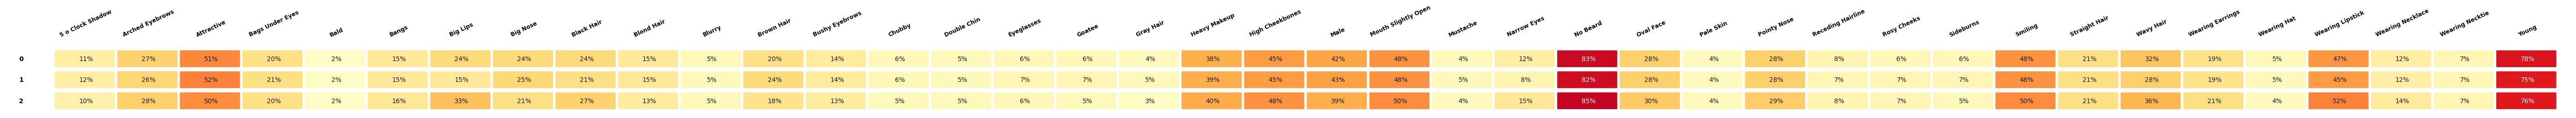

In [67]:
plot_table_attr(attr_binary, colonnes_attributs)

Les écarts de distribution sont minimes sur la quasi-totalité des attributs. Le split train/val/test est **découpé de manière satisfaisante** : la distribution de *Smiling* (cible) et des attributs sensibles (*Young*, *Wearing_Lipstick*, etc.) est homogène entre partitions. Les résultats d'évaluation sont donc comparables et non biaisés par le découpage.

### Entraîner un modèle en utilisant les images en entrée et l’attribut Smiling.. Justifier le choix de votre modèle. Décrivez et commentez les résultats.

In [68]:
path_image = resolve_celeba_image_dir(faces.path)
print(path_image)
for root, dirs, files in os.walk(path_image):
    level = root.replace(path_image, "").count(os.sep)
    print(dirs)
    if level < 2:
        subindent = ' ' * 2 * level
        print(f"{subindent}{os.path.basename(root)}/")

        subindent_files = ' ' * 2 * (level + 1)
        for file in files[:5]:
            print(f'{subindent_files}{file}')

/Users/constance/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2/img_align_celeba/img_align_celeba
[]
img_align_celeba/
  052628.jpg
  110369.jpg
  161590.jpg
  065084.jpg
  108526.jpg


On embed à présent les images grâce à un modèle ResNet pré-entrainé.

In [69]:
import importlib
import data_analysis
from IPython.display import display
from torchvision import models
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch import nn

importlib.reload(data_analysis)
from data_analysis import *


In [70]:
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())
print(torch.backends.mps.is_available())

mps
False
True


In [71]:
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
backbone.fc = nn.Identity()
backbone    = backbone.to(device).eval()

In [72]:
table = faces.data["attr_df"].merge(faces.data["partition_df"], on='image_id', how='inner')  # on le refait pour éviter tout data leakage

splits = {}
for name, pid in [("train", 0), ("valid", 1), ("test", 2)]:
    sub = table[table["partition"] == pid].reset_index(drop=True)
    splits[name] = (sub["image_id"], sub["Smiling"])

X_train, y_train = splits["train"]
X_valid, y_valid = splits["valid"]
X_test, y_test = splits["test"]

In [73]:
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

In [74]:
train_ds = CelebADataset(X_train, y_train, path_image, transform)
valid_ds = CelebADataset(X_valid, y_valid, path_image, transform)
test_ds  = CelebADataset(X_test,  y_test,  path_image, transform)

F_train, y_train_np = load_or_compute_embeddings(train_ds, backbone, device, "cache/train.npz")
F_valid, y_valid_np = load_or_compute_embeddings(valid_ds, backbone, device, "cache/valid.npz")
F_test,  y_test_np  = load_or_compute_embeddings(test_ds,  backbone, device, "cache/test.npz")


In [75]:
train_ds.load_features(F_train)
valid_ds.load_features(F_valid)
test_ds.load_features(F_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

In [76]:
head = nn.Sequential(       
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
).to(device)

optimizer = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

In [77]:
# Debug rapide — à lancer avant la boucle
features, labels = next(iter(train_loader))
print("features:", features.shape, features.mean(), features.std())
print("labels:  ", labels.shape, labels.unique())
print("logits:  ", head(features.to(device)).shape)

features: torch.Size([256, 2048]) tensor(0.0719) tensor(0.2988)
labels:   torch.Size([256]) tensor([0, 1])
logits:   torch.Size([256, 1])


In [78]:
for epoch in range(20):
    train_loss, train_acc = run_epoch(head, criterion, optimizer, train_loader, device, train=True)
    valid_loss, valid_acc = run_epoch(head, criterion, optimizer, valid_loader, device, train=False)
    print(f"Epoch {epoch+1:02d} | "
          f"train {train_loss:.4f} / {train_acc:.3f} | "
          f"val   {valid_loss:.4f} / {valid_acc:.3f}")

Epoch 01 | train 0.3600 / 0.838 | val   0.3216 / 0.861
Epoch 02 | train 0.3207 / 0.859 | val   0.3122 / 0.865
Epoch 03 | train 0.3107 / 0.864 | val   0.3094 / 0.866
Epoch 04 | train 0.3050 / 0.866 | val   0.3051 / 0.867
Epoch 05 | train 0.3001 / 0.869 | val   0.3027 / 0.867
Epoch 06 | train 0.2947 / 0.871 | val   0.3131 / 0.862
Epoch 07 | train 0.2918 / 0.873 | val   0.3060 / 0.866
Epoch 08 | train 0.2891 / 0.874 | val   0.3012 / 0.868
Epoch 09 | train 0.2857 / 0.876 | val   0.2992 / 0.871
Epoch 10 | train 0.2817 / 0.878 | val   0.3008 / 0.870
Epoch 11 | train 0.2794 / 0.879 | val   0.2967 / 0.871
Epoch 12 | train 0.2748 / 0.881 | val   0.3008 / 0.868
Epoch 13 | train 0.2737 / 0.882 | val   0.3119 / 0.866
Epoch 14 | train 0.2714 / 0.883 | val   0.3037 / 0.869
Epoch 15 | train 0.2675 / 0.886 | val   0.3034 / 0.868
Epoch 16 | train 0.2647 / 0.886 | val   0.3020 / 0.871
Epoch 17 | train 0.2618 / 0.888 | val   0.3080 / 0.869
Epoch 18 | train 0.2595 / 0.888 | val   0.3067 / 0.869
Epoch 19 |

In [79]:
test_loss, test_acc = run_epoch(head, criterion, optimizer, test_loader, device, train=False)
print(f"\nTest | loss {test_loss:.4f} | acc {test_acc:.3f}")


Test | loss 0.3137 | acc 0.863


In [80]:
model = FullModel2Class(backbone, head).to(device)
model.eval()

FullModel2Class(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

#### Choix du modèle — Transfer Learning avec ResNet-50

L'approche retenue est un **feature extractor figé + tête de classification légère**, justifiée par plusieurs raisons :

- **ResNet-50 pré-entraîné sur ImageNet** fournit des représentations visuelles riches et généralisables (textures, formes, structures faciales) sans nécessiter d'entraînement complet sur CelebA.
- **Geler le backbone** (`eval()`, seule la tête est optimisée) réduit drastiquement le coût computationnel et le risque d'overfitting, tout en exploitant des features de bas niveau déjà pertinentes pour la détection faciale.
- **La tête légère** (2048→256→1) est suffisante pour une tâche binaire à partir de features déjà très discriminantes.
- **BCEWithLogitsLoss** est le choix naturel pour une classification binaire, plus stable numériquement que BCE + Sigmoid séparés.


#### Analyse des courbes d'entraînement

**Convergence rapide** — Dès l'epoch 2, la val accuracy atteint 86.5% et se stabilise. Le modèle apprend l'essentiel en très peu d'epochs.

**Écart train/val croissant** — La train loss descend continûment (0.360 → 0.253) tandis que la val loss oscille autour de 0.300 sans descendre significativement après l'epoch 5. C'est un signal d'**overfitting léger de la tête**, sans impact majeur sur l'accuracy.

**Val accuracy plateau** — Elle se stabilise entre 0.867 et 0.871 dès l'epoch 4, ce qui suggère que 5 à 8 epochs auraient suffi. Les epochs suivantes n'apportent pas de gain de généralisation.


#### Résultats test

| Métrique | Valeur |
|----------|--------|
| Loss | 0.3137 |
| Accuracy | **0.863** |

La performance test (86.3%) est cohérente avec la val accuracy, ce qui confirme une **bonne généralisation**. Elle est légèrement inférieure au meilleur val (87.1%), ce qui est attendu.

### Limite

Le backbone est figé : un fine-tuning des dernières couches de ResNet-50 permettrait probablement de gagner 1 à 2 points d'accuracy.

### Évaluation de l’équité: Comparer les performances par sous-groupes sensibles : (e.g. Accuracy par genre, FPR / FNR par groupe, Écart de performance entre groupes)

Pour chaque attribut sensible, on partitionne indépendamment le test set en deux sous-groupes (-1 / +1) — sans exclusivité, un individu peut figurer dans plusieurs partitions. On calcule accuracy, FPR et FNR par groupe, puis l'écart absolu (Delta) entre les deux. Un Delta élevé signale un biais du modèle vis-a-vis de cet attribut.

In [81]:
attributs_sensibles = ["Male", "Pale_Skin", "Young", "Chubby"]

On évalue l'équité sur les données présentes dans le test set.

In [82]:
path_image = resolve_celeba_image_dir(faces.path)
fairness_test_ds = CelebADataset(X_test, y_test, path_image, transform)
fairness_loader = DataLoader(fairness_test_ds, batch_size=32, shuffle=False)

In [83]:
sensitive_test = attr_partition[attr_partition['partition'] == 2][['image_id', *attributs_sensibles]].copy()
report = fairness_report_dataloader_streaming_imgid(
    model,
    fairness_loader,
    sensitive_test,
    threshold=0.5,
    device=device,
    img_id_col='image_id',
)
print(report.to_string())

                 N  Accuracy    FPR    FNR  Δ_Acc  Δ_FPR  Δ_FNR
Group                                                          
Male=0       12247     0.873  0.101  0.146  0.026  0.044  0.148
Male=1        7715     0.848  0.057  0.294  0.026  0.044  0.148
Pale_Skin=0  19122     0.862  0.082  0.192  0.038  0.025  0.008
Pale_Skin=1    840     0.900  0.057  0.184  0.038  0.025  0.008
Young=0       4848     0.829  0.103  0.236  0.046  0.029  0.058
Young=1      15114     0.875  0.074  0.178  0.046  0.029  0.058
Chubby=0     18904     0.867  0.079  0.187  0.073  0.047  0.080
Chubby=1      1058     0.794  0.126  0.268  0.073  0.047  0.080


#### Tableau synthétique

| Attribut | Δ_Acc | Δ_FPR | Δ_FNR | Groupe désavantagé |
|----------|-------|-------|-------|-------------------|
| Male | 0.026 | 0.044 | **0.148** | Male=1 (FNR élevé) |
| Pale_Skin | 0.038 | 0.025 | 0.008 | Pale_Skin=0 (Acc plus faible) |
| Young | 0.046 | 0.029 | 0.058 | Young=0 |
| Chubby | **0.073** | **0.047** | **0.080** | Chubby=1 |


#### Analyse par attribut

**Genre (Male)** — L'écart d'accuracy est faible (0.026), mais le Δ_FNR est très élevé (**0.148**). Les hommes sont beaucoup plus souvent classifiés *not smiling* alors qu'ils sourient réellement (FNR 29.4% vs 14.6%). Le modèle détecte moins bien le sourire masculin, probablement parce que les sourires masculins sont moins expressifs ou moins représentés à l'entraînement.

**Pale_Skin** — Les écarts sont faibles sur toutes les métriques. La peau claire est légèrement avantagée en accuracy, mais le biais reste marginal.

**Young** — Δ_Acc modéré (0.046) et Δ_FNR notable (0.058). Les individus non jeunes sont systématiquement moins bien servis sur toutes les métriques, cohérent avec leur sous-représentation observée dans l'analyse des personas.

**Chubby** — L'attribut le plus problématique. Δ_Acc = **0.073**, Δ_FPR = **0.047**, Δ_FNR = **0.080**. Le groupe *Chubby=1* cumule une accuracy plus faible (0.794), plus de faux positifs et plus de faux négatifs. Ce groupe est petit (N=1058, ~5% du test set), ce qui suggère une sous-représentation à l'entraînement.

## 3. Explication post-hoc

### Appliquez deux méthodes d’explication post-hoc

On utilise ici deux méthodes d'explication post-hoc sur les images: Grad-CAM puis SHAP.


### Générer des explications locales pour un cas correct, un cas incorrect et un cas de groupe minoritaire

In [ ]:
explain_ctx = prepare_image_explanation_context(backbone, head, device, path_image)
explain_data = prepare_image_explanation_cases(
    explain_ctx,
    test_ds,
    sensitive_test,
    attributs_sensibles,
)

cases = explain_data["cases"]
print(
    f"Sous-groupe minoritaire retenu: "
    f"{explain_data['minority_attr']}={explain_data['minority_value']} "
    f"(n={explain_data['minority_count']})"
)
display(explain_data["case_summary"])
display(explain_data["group_counts"].head(len(attributs_sensibles) * 2))

Sous-groupe minoritaire retenu: Pale_Skin=1 (n=840)


,image_id,y_true,y_pred,prob_smiling,correct,minority_group
correct,182638.jpg,1,1,0.998,True,NaN
incorrect,182645.jpg,0,1,0.59,False,NaN
minority,182657.jpg,1,1,0.994,True,Pale_Skin=1 (n=840)


,value,count,attribute
0,1,840,Pale_Skin
1,1,1058,Chubby
2,0,4848,Young
3,1,7715,Male
4,0,12247,Male
5,1,15114,Young
6,0,18904,Chubby
7,0,19122,Pale_Skin


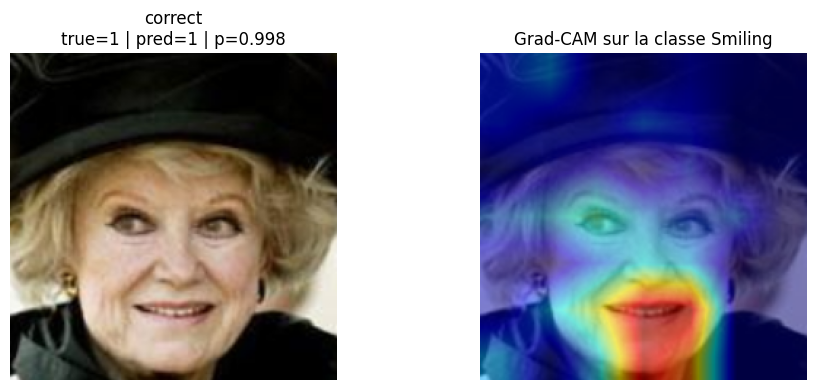

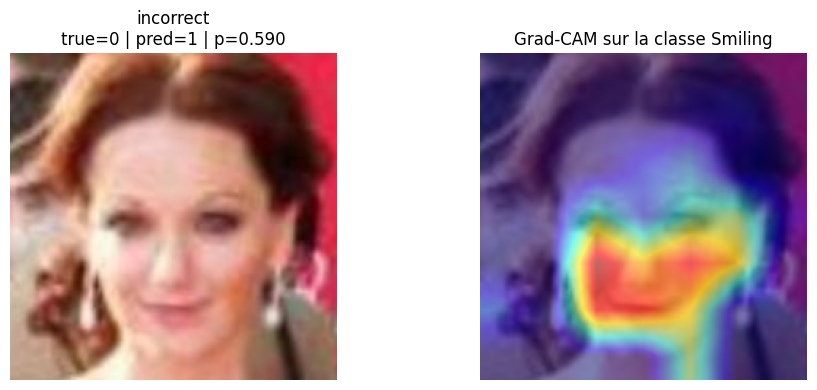

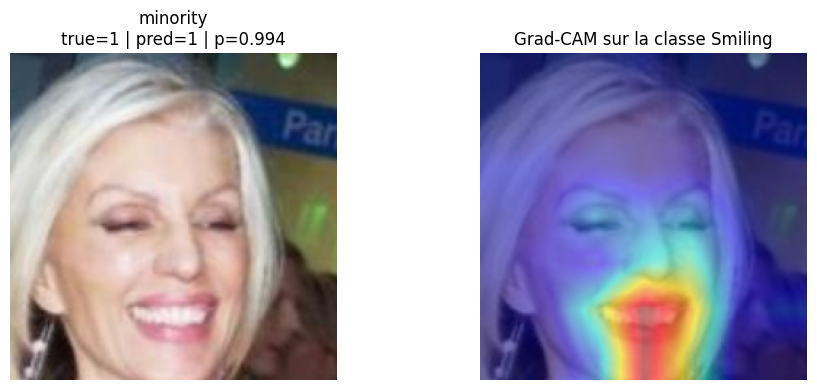

In [85]:
show_gradcam_explanations(explain_ctx, cases)

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:50, 50.03s/it]               

correct: 182638.jpg | true=1 | pred=1 | p=0.998


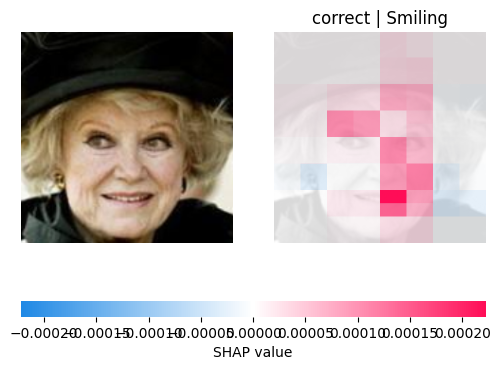

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:45, 45.01s/it]               

incorrect: 182645.jpg | true=0 | pred=1 | p=0.590


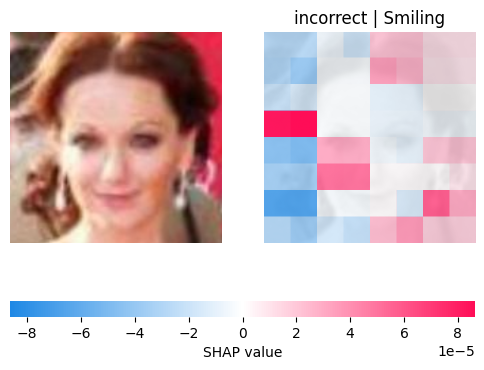

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:43, 43.17s/it]               

minority: 182657.jpg | true=1 | pred=1 | p=0.994


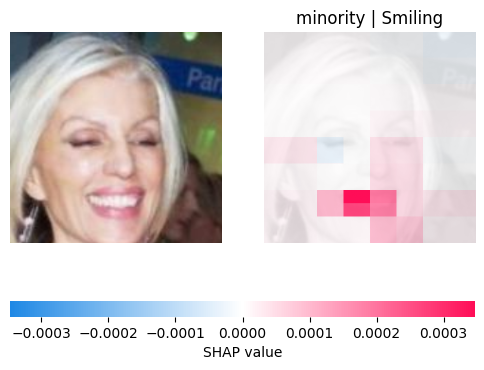

In [86]:
show_shap_explanations(explain_ctx, cases, max_evals=300, batch_size=16)

### commenter et conclure sur votre modèle.

Le modèle a appris le bon concept. 
L'analyse Grad-CAM montre que le gradient du score de prédiction, rétropropagé jusqu'à la dernière couche convolutive du backbone ResNet, se concentre de manière cohérente sur le bas du visage. La zone d'activation est toutefois légèrement plus large que la bouche stricto sensu : cela s'explique par le fait qu'un sourire induit des modifications morphologiques diffuses à ce niveau ce qui élargit naturellement le champ d'attention du modèle.
L'analyse SHAP, reposant sur un masquage par superpixels de grande taille, offre une localisation plus grossière. Elle confirme néanmoins la même tendance : dans les cas de prédiction correcte, la région d'intérêt identifiée correspond bien au bas du visage. En revanche, dans les cas d'erreur, l'attention du modèle se porte sur des zones non pertinentes, ce qui suggère que les mauvaises prédictions ne relèvent pas d'une incertitude sur le bon concept, mais d'une activation parasite sur une autre région de l'image.

### Si le modèle n’a pas appris le bon concept, proposer une intervention et recommencer.

Le modèle a bien appris le bon concept.